In [35]:
#Importation des bibliotheques
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.model_selection import train_test_split,GridSearchCV 
from matplotlib import pyplot as plt
import seaborn as sns

In [36]:
#Chargement du dataset digits
digits=datasets.load_digits()
#Séparation train/test
(x_train,x_test,y_train,y_test)=train_test_split(digits.data,digits.target,test_size=0.2,random_state=42)



Accuracy: 0.9777777777777777
Rapport de classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.94      0.96        34
           4       0.98      0.98      0.98        46
           5       0.96      1.00      0.98        47
           6       1.00      1.00      1.00        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



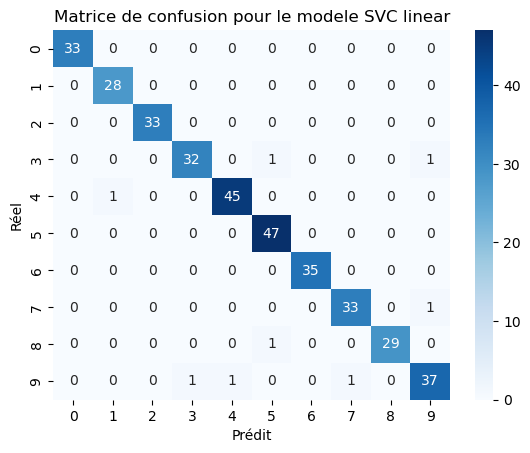

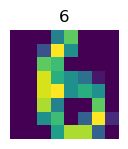

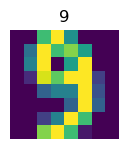

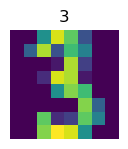

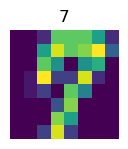

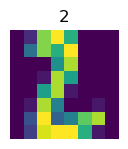

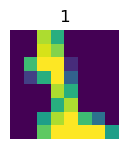

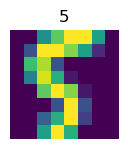

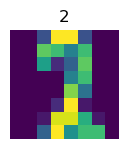

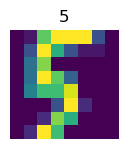

In [37]:
#Entrainement du modele SVC linear 
svm_linear=SVC(kernel='linear')
svm_linear.fit(x_train,y_train)
#Prédiction pour le modele SVC linear
y_predict_linear=svm_linear.predict(x_test)
#Evaluation pour le modele SVC linear
print("Accuracy:",accuracy_score(y_test,y_predict_linear))
print("Rapport de classification:")
print(classification_report(y_test,y_predict_linear))
#Matrice de confusion pour le modele SVC linear
cm_linear=confusion_matrix(y_test,y_predict_linear)
sns.heatmap(cm_linear,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour le modele SVC linear")
plt.show()
#visualisation pour le modele SVC linear
plt.figure
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(8,8))
    plt.title(y_predict_linear[i])
    plt.axis('off')
    plt.show()
    


Accuracy: 0.9916666666666667
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       1.00      0.98      0.99        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      1.00      1.00        30
           9       0.97      0.97      0.97        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



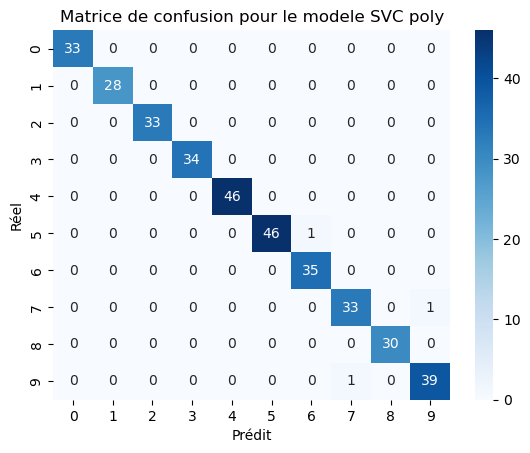

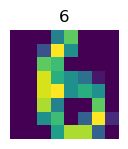

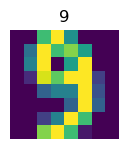

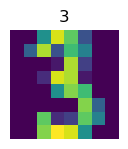

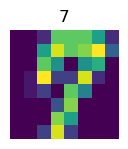

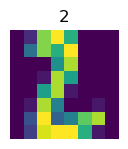

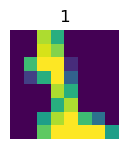

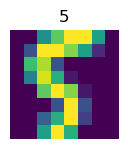

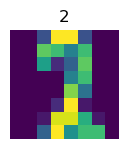

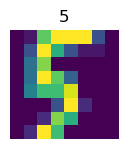

In [38]:
#Entrainement du modele SVC poly
svm_poly=SVC(kernel='poly',degree=3)
svm_poly.fit(x_train,y_train)
#Prédiction pour le modele SVC poly
y_predict_poly=svm_poly.predict(x_test)
#Evaluation pour le modele SVC poly
print("Accuracy:",accuracy_score(y_test,y_predict_poly))
print("Classification report:")
print(classification_report(y_test,y_predict_poly))
#Matrice de confusion pour le modele SVC poly
cm_poly=confusion_matrix(y_test,y_predict_poly)
sns.heatmap(cm_poly,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour le modele SVC poly")
plt.show()
#Visualisation pour le modele SVC poly
plt.figure
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(8,8))
    plt.title(y_predict_poly[i])
    plt.axis('off')
    plt.show()
    


Accuracy: 0.9861111111111112
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



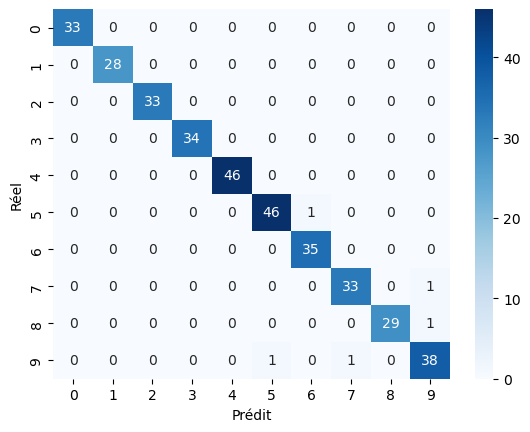

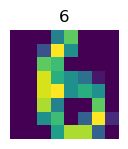

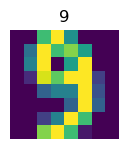

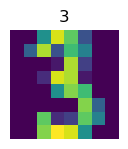

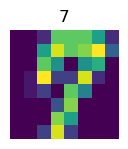

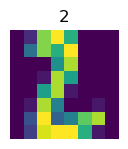

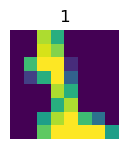

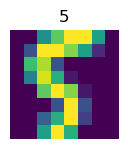

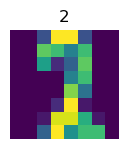

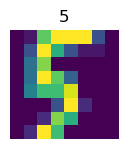

In [39]:
#Entrainement du modele SVC rbf
svm_rbf=SVC(kernel='rbf')
svm_rbf.fit(x_train,y_train)
#Prédiction pour le modele SVC rbf
y_predict_rbf=svm_rbf.predict(x_test)
#Evaluation pour le modele SVC rbf
print("Accuracy:",accuracy_score(y_test,y_predict_rbf))
print("Classification report:")
print(classification_report(y_test,y_predict_rbf))
#Matrice de confusion pour le modele SVC rbf
cm_rbf=confusion_matrix(y_test,y_predict_rbf)
sns.heatmap(cm_rbf,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()
#Visualisation pour le modele SVC rbf
plt.figure
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(8,8))
    plt.title(y_predict_rbf[i])
    plt.axis("off")
    plt.show()

In [40]:
#GridSearchCV
param_grid=[
    {'kernel':['linear'],'C':[0.1,1,10]},
    {'kernel':['poly'],'C':[0.1,1,10],'degree':[2,3,4]},
    {'kernel':['rbf'],'C':[0.1,1,10],'gamma':['scale',0.1,0.01]}
]
grid=GridSearchCV(SVC(),param_grid,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
print("Best Paarameters:",grid.best_params_)
print("Best CV score:",grid.best_score_)
y_predict_best=grid.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_predict_best))

Best Paarameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9916545683313978
Accuracy: 0.9861111111111112
